# Phase 3: Temporal Fusion Transformer

In this notebook we:
1. Load the quarterly panel
2. Build a TimeSeriesDataSet
3. Split into train/validation
4. Train a TFT
5. Generate and save multi‐horizon quantile forecasts

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import logging
from pathlib import Path
from typing import Dict, Tuple


# Add LightGBM
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Target encoding
import category_encoders as ce



# ──────────────────────────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")
logger = logging.getLogger(__name__)


project_root = Path.cwd().parent  # assumes you're in /notebooks
sys.path.append(str(project_root))

           # adjust to your repo root
data_dir     = project_root / 'data' / 'processed'
agg_dir      = project_root / 'data' / 'aggregated'

data_path = agg_dir / "modeling_panel_project.csv"
df = pd.read_csv(data_path)
logger.info(f"Loaded {df.shape[0]} rows, {df.shape[1]} cols")

projects_meta = pd.read_csv(data_dir / "projects.csv")



2025-05-26 18:13:28,928 INFO: Loaded 14819 rows, 344 cols


In [3]:
# Drop high-cardinality/free-text/date cols except field hierarchy for encoding
drop_cols = [
    "acronym", "title", "objective", "content_update_date",
    "rcn", "grant_doi", "coordinator_name", "status",
    "start_date", "end_date"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df['ec_signature_date'] = pd.to_datetime(df['ec_signature_date'])
df['year_signed']    = df['ec_signature_date'].dt.year.astype('category')
df['quarter_signed'] = df['ec_signature_date'].dt.quarter.astype('category')
df['year'] = df['ec_signature_date'].dt.year
df['funding_log1p'] = np.log1p(df['funding'])


call_year = (
    df.groupby(['master_call','year'])['funding']
      .mean()
      .reset_index(name='call_year_avg')
)
df = df.merge(call_year, on=['master_call','year'], how='left')

slopes = []
for call, grp in df.groupby('master_call'):
    years = sorted(grp['year'].unique())
    if len(years) >= 3:
        last3 = years[-3:]
        vals  = grp[grp['year'].isin(last3)].groupby('year')['funding'].mean().values
        slope = np.polyfit(last3, vals, 1)[0]
    else:
        slope = 0.0
    slopes.append({'master_call': call, 'call_trend_slope': slope})
slopes = pd.DataFrame(slopes)
df = df.merge(slopes, on='master_call', how='left')

# Usual categorical cols
categorical_cols = [
    'master_call', 'sub_call', 'funding_scheme',
    'coord_country', 'coord_activity_type', 'coord_sme', 'field_class'
]
categorical_cols = [c for c in categorical_cols if c in df.columns]
for c in categorical_cols:
    df[c] = df[c].astype("category")


In [4]:
# %%  
# ──────────────────────────────────────────────────────────────────────────────
# 1) Train/test split
train_mask = df['ec_signature_date'] <= "2023-12-31"
test_mask  = df['ec_signature_date'] >  "2023-12-31"
df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

# 2) Re-cast categoricals on each split
for c in categorical_cols:
    df_train[c] = df_train[c].astype("category")
    df_test[c]  = df_test[c].astype("category")

# ──────────────────────────────────────────────────────────────────────────────
# 3) Leak-free call-trend features (train only)
# 3a) Per-call per-year average funding
call_year = (
    df_train.groupby(['master_call','year'])['funding']
            .mean()
            .reset_index(name='call_year_avg')
)

# 3b) Per-call trend slope over the last 3 years
slopes = []
for call, grp in df_train.groupby('master_call'):
    yrs = sorted(grp['year'].unique())
    if len(yrs) >= 3:
        last3 = yrs[-3:]
        vals  = grp[grp['year'].isin(last3)] \
                   .groupby('year')['funding'].mean().values
        slope = np.polyfit(last3, vals, 1)[0]
    else:
        slope = 0.0
    slopes.append({'master_call': call, 'call_trend_slope': slope})
slopes = pd.DataFrame(slopes)

# 3c) Merge train-based stats into both train & test
for d in (df_train, df_test):
    d[:] = d.merge(call_year, on=['master_call','year'], how='left')
    d[:] = d.merge(slopes,   on='master_call',      how='left')

# 4) Target encode the scientific hierarchy
hierarchy_cols = [c for c in ["field","sub_field","niche"] if c in df_train.columns]
encoder = ce.TargetEncoder(cols=hierarchy_cols, smoothing=0.3) \
            .fit(df_train[hierarchy_cols], df_train['funding_log1p'])
df_train[hierarchy_cols] = encoder.transform(df_train[hierarchy_cols])
df_test[hierarchy_cols]  = encoder.transform(df_test[hierarchy_cols])

# ──────────────────────────────────────────────────────────────────────────────
# 5) Build feature matrices
exclude = ['funding','funding_log1p','ec_signature_date','year']
feature_cols = [c for c in df.columns if c not in exclude]

X_train = df_train[feature_cols]
X_test  = df_test[feature_cols]
y_train = df_train['funding_log1p']
y_test  = df_test['funding']

logger.info(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

cat_feat_idx = [X_train.columns.get_loc(c) for c in categorical_cols if c in X_train.columns]

C:\Users\suley\AppData\Local\Temp\ipykernel_16120\294917148.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train.groupby(['master_call','year'])['funding']
C:\Users\suley\AppData\Local\Temp\ipykernel_16120\294917148.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for call, grp in df_train.groupby('master_call'):
2025-05-26 18:13:29,918 INFO: X_train shape: (9696, 336), y_train shape: (9696,)


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# 6) Two-Stage “Bulk vs Mega” Cascade
# 6a) Identify bulk (≤99th percentile) vs mega
thresh = df_train['funding'].quantile(0.99)
df_train['is_mega'] = (df_train['funding'] > thresh).astype(int)
df_test ['is_mega'] = (df_test ['funding'] > thresh).astype(int)

# 6b) Train bulk model
bulk_idx = df_train['is_mega'] == 0
Xb, yb   = X_train[bulk_idx], y_train[bulk_idx]
m_bulk = LGBMRegressor(
    objective="tweedie",
    tweedie_variance_power=1.5,
    num_leaves=127, max_depth=12,
    learning_rate=0.05, n_estimators=1500,
    random_state=42, verbose=-1
)
m_bulk.fit(Xb, yb, categorical_feature=cat_feat_idx)

# 6c) Train mega model
mega_idx = df_train['is_mega'] == 1
Xm, ym   = X_train[mega_idx], y_train[mega_idx]
m_mega = LGBMRegressor(
    objective="gamma",
    num_leaves=63, max_depth=8,
    learning_rate=0.05, n_estimators=800,
    random_state=42, verbose=-1
)
if len(Xm) > 5:
    m_mega.fit(Xm, ym, categorical_feature=cat_feat_idx)
else:
    m_mega = m_bulk  # fallback

In [6]:
# 7) Predict & Evaluate
# 7a) Two-stage predictions on test
y_pred_log = np.empty(len(X_test), dtype=float)
 # explicit boolean masks
mask_bulk  = (df_test['is_mega'] == 0).values
mask_mega  = (df_test['is_mega'] == 1).values
idx_bulk   = np.where(mask_bulk)[0]
idx_mega   = np.where(mask_mega)[0]

y_pred_log[idx_bulk] = m_bulk.predict(X_test.iloc[idx_bulk])
y_pred_log[idx_mega] = m_mega.predict(X_test.iloc[idx_mega])
y_pred = np.expm1(y_pred_log)

# 7b) Metrics per slice
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def slice_metrics(mask, label):
    n = mask.sum()
    y_t = y_test.values[mask]
    y_p = y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    r2   = r2_score(y_t, y_p) if n>1 else np.nan
    print(f"{label} → n={n}: RMSE={rmse:,.0f}, MAE={mae:,.0f}, R²={r2:.3f}")

slice_metrics(mask_bulk, "Bulk")
slice_metrics(mask_mega, "Mega")

# overall
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred))
mae_all  = mean_absolute_error(y_test, y_pred)
r2_all   = r2_score(y_test, y_pred)
print(f"Overall → n={len(y_test)}: RMSE={rmse_all:,.0f}, MAE={mae_all:,.0f}, R²={r2_all:.3f}")


Bulk → n=5095: RMSE=856,387, MAE=322,446, R²=0.900
Mega → n=28: RMSE=78,237,623, MAE=32,813,602, R²=0.176
Overall → n=5123: RMSE=5,846,768, MAE=500,028, R²=0.480


Top 15 features (bulk):
 ec_contribution_per_year    6662
project_id                  4462
n_institutions              4361
call_year_avg               4060
duration_days               3713
master_call                 3640
coord_country               3446
total_cost                  3157
field_class                 2654
deliverable_count           2432
field                       1990
niche                       1723
publication_count           1432
13                          1421
sub_field                   1285
dtype: int32


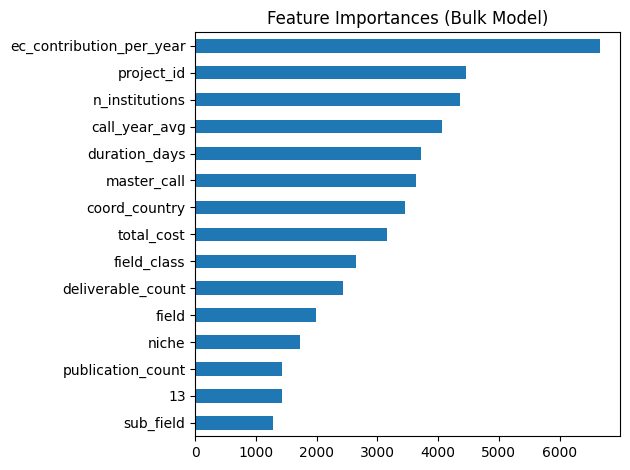

Top 15 features (mega):
 ec_contribution_per_year    263
project_id                  205
deliverable_count           182
duration_days               181
call_year_avg               152
104                         152
149                          98
169                          97
publication_count            84
n_institutions               80
28                           68
32                           67
55                           48
quarter_signed               42
sub_field                    41
dtype: int32


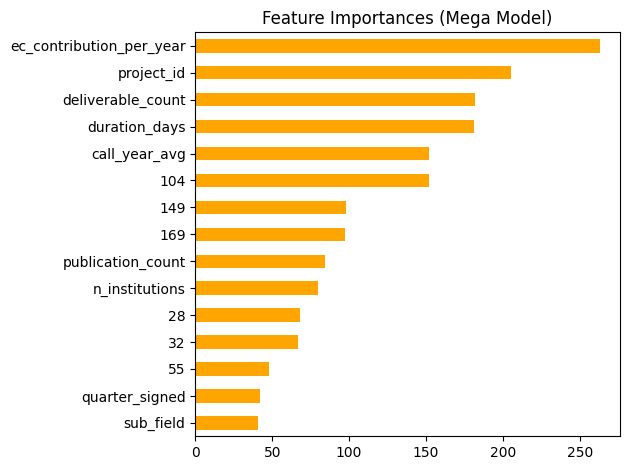

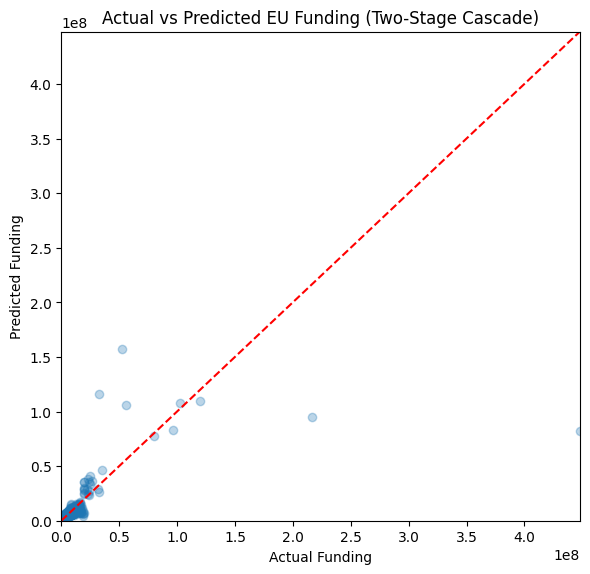

In [7]:
# ----------- Feature Importances -----------
importances_bulk = pd.Series(m_bulk.feature_importances_, index=Xb.columns) \
                    .sort_values(ascending=False).head(15)
print("Top 15 features (bulk):\n", importances_bulk)
importances_bulk.plot(kind='barh', title='Feature Importances (Bulk Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances_mega = pd.Series(m_mega.feature_importances_, index=Xm.columns) \
                    .sort_values(ascending=False).head(15)
print("Top 15 features (mega):\n", importances_mega)
importances_mega.plot(kind='barh', color='orange', title='Feature Importances (Mega Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ----------- Overall Actual vs Predicted Scatter -----------
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual Funding")
plt.ylabel("Predicted Funding")
plt.title("Actual vs Predicted EU Funding (Two-Stage Cascade)")
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# ──────────────────────────────────────────────────────────────────────────────
# 1) Load metadata & test split
projects_meta = pd.read_csv(f"{data_dir}/projects.csv")

# keep only the columns that actually exist in your file
projects_meta = projects_meta[[
    "id","acronym","title","ec_max_contribution",
    "master_call","funding_scheme","field_class","ec_signature_date"
]]

# assume df_test already exists (with project_id, funding & e.g. coord_country,…)
# and you have y_pred = your model’s predictions (on original scale)
df = df_test.copy().reset_index(drop=True).assign(predicted=y_pred)

# ──────────────────────────────────────────────────────────────────────────────
# 2) Build the display DataFrame
df_vis = (
    df
    .merge(
        projects_meta,
        left_on  = "project_id",
        right_on = "id",
        how      = "left"
    )
    .rename(columns={"ec_max_contribution":"actual"})
    .dropna(subset=["actual"])   # drop rows with no initial funding
    .assign(
        error_abs = lambda d: (d.predicted - d.actual).abs(),
        error_pct = lambda d: 100 * d.error_abs / d.actual
    )
    .reset_index(drop=True)
)

# pick a nice label: acronym or title or project_id
df_vis["display_name"] = (
    df_vis["acronym"]
      .fillna(df_vis["title"])
      .fillna("Proj "+df_vis["project_id"].astype(str))
)
df_vis["idx"] = df_vis.index

# ──────────────────────────────────────────────────────────────────────────────
# 3) Dashboard function
def make_dashboard(df_vis):
    chooser = widgets.Dropdown(
        options=[(nm, i) for i,nm in zip(df_vis["idx"], df_vis["display_name"])],
        value=df_vis["idx"].iloc[0],
        description="Project:",
        layout=widgets.Layout(width="350px")
    )
    out = widgets.Output()
    
    def render(idx):
        row = df_vis.loc[df_vis["idx"]==idx].iloc[0]
        
        # safely grab metadata from the row
        name   = row["display_name"]
        call   = row.get("master_call", "")
        scheme = row.get("funding_scheme", "")
        field  = row.get("field_class", "")
        signed = pd.to_datetime(row.get("ec_signature_date")).date() \
                   if pd.notna(row.get("ec_signature_date")) else ""
        
        # build metadata HTML
        meta = f"""
        <table style="border-collapse:collapse;margin-bottom:10px">
          <tr><th align="left">Name</th>   <td>{name}</td></tr>
          <tr><th align="left">Call</th>   <td>{call}</td></tr>
          <tr><th align="left">Scheme</th> <td>{scheme}</td></tr>
          <tr><th align="left">Field</th>  <td>{field}</td></tr>
          <tr><th align="left">Signed</th> <td>{signed}</td></tr>
        </table>
        <p>
          <b>Absolute Error:</b> €{row['error_abs']:,.0f}<br>
          <b>% Error:</b> {row['error_pct']:.1f}%
        </p>
        """
        # grouped bar chart
        bar = go.FigureWidget(
            data=[
                go.Bar(name="Initial (€)",  x=[""], y=[row["actual"]]),
                go.Bar(name="Expected (€)", x=[""], y=[row["predicted"]])
            ],
            layout=go.Layout(
                title="Funding Comparison",
                barmode="group",
                yaxis={"title":"€"},
                margin={"t":40,"b":30,"l":50,"r":10},
                height=300
            )
        )
        
        with out:
            out.clear_output(wait=True)
            display(widgets.HTML(meta))
            display(bar)
    
    chooser.observe(lambda ev: render(ev.new), names="value")
    render(chooser.value)
    display(widgets.VBox([chooser, out], layout=widgets.Layout(padding="10px")))

# finally, call it:
make_dashboard(df_vis)
